# AndinaLog 03B · Evidencia 3 · Contrato 1: regresión térmica

**Pregunta:** con lo conocido en una lectura del viaje, ¿cuál será el mayor desvío respecto al umbral de conservación durante los siguientes 60 minutos?

Este cuaderno adapta el flujo de la sesión 6 a los Silver de AndinaLog. No modifica los Silver ni usa el indicador binario como objetivo. El resultado es un experimento retrospectivo, no una alerta validada en operación.

**Contrato predictivo**

| Elemento | Definición |
|---|---|
| Decisión | Priorizar la revisión o intercepción de un camión cuando se anticipe un desvío térmico relevante. |
| Unidad | Una lectura IoT identificada por `viaje_id` y `timestamp`. |
| Momento y horizonte | Predicción en `timestamp`; máximo observado estrictamente después de ese instante y hasta 60 minutos más tarde. |
| Objetivo `y` | Máximo futuro de `abs(temperatura_cabina_c - temperatura_conservacion_requerida_c) - tolerancia_temperatura_c`, medido en °C respecto al límite. Puede ser negativo si toda la ventana permanece dentro del límite. |
| `X` | Temperatura y humedad actuales, temperatura anterior, cambio por minuto, distancia actual al umbral, categoría logística y tipo de camión. |
| Exclusiones | Objetivo futuro, bandera de los próximos 60 minutos, banderas posteriores, IDs y cualquier columna conocida tras la lectura. |

La guía v8 también menciona eventos previos de flota y atributos del pedido. Se omiten en esta primera versión porque este cuaderno usa los tres Silver ya integrados en el EDA 3; podrían agregarse solo tras verificar su instante de disponibilidad y sus uniones.


## 1. Carga de Silver

La ruta local apunta al repositorio actual. Si se ejecuta en Colab, ajusta `RUTA_PROYECTO_DRIVE` a la carpeta donde están los Silver. El localizador verifica que cada archivo exista antes de continuar.


In [13]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ENTORNO = "auto"  # auto, local o drive
RUTA_PROYECTO_DRIVE = "/content/drive/MyDrive/GIAD"
RUTA_PROYECTO_LOCAL = Path(r"C:\Users\remrodri\Github\practicasNotebookColab")
RUTAS_MANUALES = {"iot": None, "productos": None, "flota": None}
FRACCION_TRAIN_OBJETIVO = 0.80
SEMILLA = 42
ARCHIVOS = {
    "iot": "andinalog_iot_telemetry_silver.csv",
    "productos": "andinalog_productos_silver.csv",
    "flota": "andinalog_flota_silver.csv",
}
SUBRUTAS = {
    "iot": ["S4/andinalog_iot_telemetry/notebook2/salidas", "proyecto-integrador/andinalog_iot_telemetry/notebook2/salidas"],
    "productos": ["proyecto-integrador/andinalog_productos/notebook2/salidas", "S4/andinalog_productos/notebook2/salidas"],
    "flota": ["proyecto-integrador/andinalog_flota/notebook2/salidas", "S4/andinalog_flota/notebook2/salidas"],
}

def raices_posibles():
    entorno = ENTORNO
    if entorno == "auto":
        entorno = "drive" if "google.colab" in sys.modules else "local"
    if entorno == "drive":
        from google.colab import drive
        drive.mount("/content/drive")
        return [Path(RUTA_PROYECTO_DRIVE)]
    if entorno == "local":
        return [RUTA_PROYECTO_LOCAL, Path.cwd(), *Path.cwd().parents]
    raise ValueError("ENTORNO debe ser auto, local o drive")

def encontrar_silver(nombre):
    manual = RUTAS_MANUALES[nombre]
    if manual is not None:
        ruta = Path(manual)
        if not ruta.is_file():
            raise FileNotFoundError(f"No existe {nombre}: {ruta}")
        return ruta
    for raiz in raices_posibles():
        for subruta in SUBRUTAS[nombre]:
            ruta = raiz / subruta / ARCHIVOS[nombre]
            if ruta.is_file():
                return ruta
    raise FileNotFoundError(f"No se encontró {ARCHIVOS[nombre]}. Indica su ruta en RUTAS_MANUALES['{nombre}'].")

rutas = {nombre: encontrar_silver(nombre) for nombre in ARCHIVOS}
for nombre, ruta in rutas.items():
    print(nombre, "→", ruta)

def leer_silver(ruta):
    return pd.read_csv(ruta, dtype="string", encoding="utf-8-sig", keep_default_na=False)

iot_raw, productos_raw, flota_raw = (leer_silver(rutas[n]) for n in ("iot", "productos", "flota"))

iot → C:\Users\remrodri\Github\practicasNotebookColab\proyecto-integrador\andinalog_iot_telemetry\notebook2\salidas\andinalog_iot_telemetry_silver.csv
productos → C:\Users\remrodri\Github\practicasNotebookColab\proyecto-integrador\andinalog_productos\notebook2\salidas\andinalog_productos_silver.csv
flota → C:\Users\remrodri\Github\practicasNotebookColab\proyecto-integrador\andinalog_flota\notebook2\salidas\andinalog_flota_silver.csv


## 2. Validación y uniones

Se conserva una fila por lectura. Los joins con Productos y Flota deben ser muchos a uno, y los viajes usados para modelar deben mantener una identidad estable de orden, producto y camión.


In [14]:
REQUERIDAS = {
    "iot": {"timestamp", "viaje_id", "order_id", "camion_id", "producto_id",
            "temperatura_cabina_c", "humedad_cabina_pct", "desviacion_termica_flag",
            "desviacion_proximos_60min_flag"},
    "productos": {"producto_id", "categoria_logistica", "temperatura_conservacion_requerida_c",
                  "tolerancia_temperatura_c"},
    "flota": {"camion_id", "tipo_camion"},
}
fuentes = {"iot": iot_raw, "productos": productos_raw, "flota": flota_raw}
for nombre, tabla in fuentes.items():
    faltantes = REQUERIDAS[nombre] - set(tabla.columns)
    if tabla.empty or faltantes:
        raise ValueError(f"{nombre}: Silver vacío o columnas faltantes {sorted(faltantes)}")
    claves = {"iot": ["viaje_id", "order_id", "camion_id", "producto_id"],
              "productos": ["producto_id"], "flota": ["camion_id"]}[nombre]
    if tabla[claves].eq("").any().any() or tabla[claves].isna().any().any():
        raise ValueError(f"{nombre}: claves vacías")
if productos_raw["producto_id"].duplicated().any() or flota_raw["camion_id"].duplicated().any():
    raise ValueError("Productos/Flota deben ser únicos por producto_id/camion_id")

iot = iot_raw.copy(deep=True)
productos = productos_raw.copy(deep=True)
flota = flota_raw.copy(deep=True)
iot["timestamp"] = pd.to_datetime(iot["timestamp"], errors="raise")
for col in ["temperatura_cabina_c", "humedad_cabina_pct", "desviacion_termica_flag",
            "desviacion_proximos_60min_flag"]:
    iot[col] = pd.to_numeric(iot[col], errors="raise")
for col in ["temperatura_conservacion_requerida_c", "tolerancia_temperatura_c"]:
    productos[col] = pd.to_numeric(productos[col], errors="raise")
if iot[["timestamp", "temperatura_cabina_c", "humedad_cabina_pct",
        "desviacion_termica_flag", "desviacion_proximos_60min_flag"]].isna().any().any():
    raise ValueError("IoT contiene mediciones, fecha o banderas nulas")
for col in ["desviacion_termica_flag", "desviacion_proximos_60min_flag"]:
    if not iot[col].isin([0, 1]).all():
        raise ValueError(f"{col} debe ser 0/1")
if iot["temperatura_cabina_c"].lt(-273.15).any() or iot["temperatura_cabina_c"].eq(-999).any():
    raise ValueError("IoT contiene temperatura imposible o centinela -999")
if not iot["humedad_cabina_pct"].between(0, 100).all():
    raise ValueError("IoT contiene humedad fuera de 0 a 100 %")
if productos[["temperatura_conservacion_requerida_c", "tolerancia_temperatura_c"]].isna().any().any():
    raise ValueError("Productos contiene parámetros térmicos nulos")
if productos["tolerancia_temperatura_c"].lt(0).any():
    raise ValueError("Productos contiene tolerancia negativa")
if iot.duplicated(["viaje_id", "timestamp"]).any():
    raise ValueError("IoT contiene viaje_id + timestamp duplicados")

display(pd.DataFrame([{"fuente": n, "filas": len(t), "columnas": len(t.columns)} for n, t in fuentes.items()]))
print("Viajes:", iot["viaje_id"].nunique(), "| periodo:", iot["timestamp"].min(), "a", iot["timestamp"].max())

,fuente,filas,columnas
0,iot,28425,10
1,productos,50,7
2,flota,28,4


Viajes: 1200 | periodo: 2026-08-01 00:10:00 a 2026-08-31 11:11:00


In [15]:
cobertura = pd.DataFrame([
    {"dimensión": "Productos", "lecturas_sin_match": int((~iot["producto_id"].isin(productos["producto_id"])).sum()),
     "claves_distintas_sin_match": int(iot.loc[~iot["producto_id"].isin(productos["producto_id"]), "producto_id"].nunique())},
    {"dimensión": "Flota", "lecturas_sin_match": int((~iot["camion_id"].isin(flota["camion_id"])).sum()),
     "claves_distintas_sin_match": int(iot.loc[~iot["camion_id"].isin(flota["camion_id"]), "camion_id"].nunique())},
])
display(cobertura)

analitico = iot.merge(
    productos[["producto_id", "categoria_logistica", "temperatura_conservacion_requerida_c",
               "tolerancia_temperatura_c"]],
    on="producto_id", how="left", validate="many_to_one", indicator="match_producto"
).merge(
    flota[["camion_id", "tipo_camion"]],
    on="camion_id", how="left", validate="many_to_one", indicator="match_flota"
)
if len(analitico) != len(iot) or analitico.duplicated(["viaje_id", "timestamp"]).any():
    raise ValueError("El join alteró la granularidad de las lecturas")
assert analitico["desviacion_proximos_60min_flag"].sum() == iot["desviacion_proximos_60min_flag"].sum()
print("Lecturas antes/después del join:", len(iot), len(analitico))
display(analitico[["match_producto", "match_flota"]].value_counts(dropna=False).rename("lecturas").reset_index())

,dimensión,lecturas_sin_match,claves_distintas_sin_match
0,Productos,4984,10
1,Flota,2389,2


Lecturas antes/después del join: 28425 28425


,match_producto,match_flota,lecturas
0,both,both,21428
1,left_only,both,4608
2,both,left_only,2013
3,left_only,left_only,376
4,both,right_only,0
5,left_only,right_only,0
6,right_only,left_only,0
7,right_only,both,0
8,right_only,right_only,0


In [16]:
identidad_viaje = analitico.groupby("viaje_id").agg(
    ordenes=("order_id", "nunique"), camiones=("camion_id", "nunique"),
    productos=("producto_id", "nunique"), lecturas=("timestamp", "size"),
)
identidad_viaje["estable"] = identidad_viaje[["ordenes", "camiones", "productos"]].eq(1).all(axis=1)
viajes_ambiguos = identidad_viaje.index[~identidad_viaje["estable"]]
print("Viajes con identidad estable:", int(identidad_viaje["estable"].sum()))
print("Viajes con varias órdenes/camiones/productos:", len(viajes_ambiguos))
print("Lecturas en viajes ambiguos:", int(analitico["viaje_id"].isin(viajes_ambiguos).sum()))
display(identidad_viaje["lecturas"].describe(percentiles=[.25, .5, .75]).to_frame("lecturas_por_viaje").round(2))
if len(viajes_ambiguos):
    display(identidad_viaje.loc[viajes_ambiguos].head(10))

Viajes con identidad estable: 1200
Viajes con varias órdenes/camiones/productos: 0
Lecturas en viajes ambiguos: 0


,lecturas_por_viaje
count,1200.00
mean,23.69
std,0.55
min,21.00
25%,23.00
50%,24.00
75%,24.00
max,24.00


## 3. Variables disponibles al predecir

Los rezagos se calculan **dentro de cada viaje**, después de ordenar por tiempo. `distancia_umbral_c` usa la temperatura de la lectura actual; no contiene datos futuros.


In [17]:
analitico = analitico.sort_values(["viaje_id", "timestamp"], kind="mergesort").reset_index(drop=True)
serie = analitico.groupby("viaje_id", sort=False)
analitico["temp_lag1_c"] = serie["temperatura_cabina_c"].shift(1)
analitico["timestamp_lag1"] = serie["timestamp"].shift(1)
analitico["min_desde_lectura_anterior"] = (
    (analitico["timestamp"] - analitico["timestamp_lag1"]).dt.total_seconds() / 60
)
if analitico["min_desde_lectura_anterior"].dropna().le(0).any():
    raise ValueError("Hay intervalos temporales no positivos dentro de un viaje")
analitico["temp_pendiente_c_por_min"] = (
    (analitico["temperatura_cabina_c"] - analitico["temp_lag1_c"])
    / analitico["min_desde_lectura_anterior"]
)
analitico["distancia_umbral_c"] = (
    (analitico["temperatura_cabina_c"] - analitico["temperatura_conservacion_requerida_c"]).abs()
    - analitico["tolerancia_temperatura_c"]
)
analitico["categoria_eda"] = analitico["categoria_logistica"].replace("", pd.NA).fillna("Sin correspondencia")
analitico["tipo_camion_eda"] = analitico["tipo_camion"].replace("", pd.NA).fillna("Sin correspondencia")
analitico["viaje_identidad_estable"] = analitico["viaje_id"].map(identidad_viaje["estable"])

print("Intervalo entre lecturas (minutos):")
display(analitico["min_desde_lectura_anterior"].describe(percentiles=[.25, .5, .75, .95]).to_frame().round(2))
print("Lecturas sin rezago (inicio de viaje):", int(analitico["temp_lag1_c"].isna().sum()))
assert int(analitico["temp_lag1_c"].isna().sum()) == analitico["viaje_id"].nunique()

Intervalo entre lecturas (minutos):


,min_desde_lectura_anterior
count,27225.00
mean,30.38
std,3.37
min,30.00
25%,30.00
50%,30.00
75%,30.00
95%,30.00
max,90.00


Lecturas sin rezago (inicio de viaje): 1200


## 4. Construcción y comprobación del objetivo futuro

Para cada lectura se calcula el máximo desvío en `(timestamp, timestamp + 60 minutos]` dentro del mismo viaje. Solo se conserva una `y` cuando el viaje tiene observaciones hasta el final del horizonte. El flag binario del Silver sirve **solo para contrastar definiciones**, nunca como predictor.

La comparación identifica desacuerdos, pero no atribuye su causa automáticamente: para eso haría falta confirmar la regla exacta con la que se generó el flag.


In [18]:
HORIZONTE = pd.Timedelta(minutes=60)
analitico["max_desvio_proximos_60min_c"] = np.nan
analitico["horizonte_completo"] = False
analitico["hay_lectura_futura_60min"] = False

for viaje_id, grupo in analitico.groupby("viaje_id", sort=False):
    posiciones = grupo.index.to_numpy()
    tiempos = grupo["timestamp"].to_numpy(dtype="datetime64[ns]")
    desvios = grupo["distancia_umbral_c"].to_numpy(dtype=float)
    fin_viaje = tiempos[-1]
    for i, pos in enumerate(posiciones):
        limite = tiempos[i] + np.timedelta64(60, "m")
        completo = limite <= fin_viaje
        j = np.searchsorted(tiempos, limite, side="right")
        hay_futuro = j > i + 1
        analitico.at[pos, "horizonte_completo"] = bool(completo)
        analitico.at[pos, "hay_lectura_futura_60min"] = bool(hay_futuro)
        if completo and hay_futuro and np.isfinite(desvios[i + 1:j]).all():
            analitico.at[pos, "max_desvio_proximos_60min_c"] = float(np.max(desvios[i + 1:j]))

TARGET = "max_desvio_proximos_60min_c"
display(pd.DataFrame({
    "control": ["Lecturas totales", "Horizonte completo", "Con lectura futura dentro del horizonte", "Objetivo calculable"],
    "lecturas": [len(analitico), int(analitico["horizonte_completo"].sum()),
                 int(analitico["hay_lectura_futura_60min"].sum()), int(analitico[TARGET].notna().sum())],
}))
if not analitico[TARGET].notna().any():
    raise ValueError("No hay objetivos de 60 minutos calculables; revisar la frecuencia y duración de los viajes")

verificables = analitico.loc[analitico[TARGET].notna(), [TARGET, "desviacion_proximos_60min_flag"]].copy()
verificables["supera_umbral_calculado"] = verificables[TARGET].gt(0).astype(int)
display(pd.crosstab(verificables["supera_umbral_calculado"],
                    verificables["desviacion_proximos_60min_flag"],
                    rownames=["Máximo futuro > 0"], colnames=["Flag Silver"]))
desacuerdos = verificables.loc[
    verificables["supera_umbral_calculado"].ne(verificables["desviacion_proximos_60min_flag"])
].copy()
print(f"Desacuerdos entre máximo futuro > 0 y flag Silver: {len(desacuerdos)} de {len(verificables)} ventanas comparables")
if len(desacuerdos):
    columnas_revision = ["viaje_id", "timestamp", "distancia_umbral_c", TARGET,
                         "desviacion_termica_flag", "desviacion_proximos_60min_flag"]
    display(analitico.loc[desacuerdos.index, columnas_revision].head(20))
print("Posibles causas a verificar en el generador: inclusión de la lectura actual, regla del umbral u horizonte.")
print("Ningún flag se utiliza como X en este contrato de regresión.")


,control,lecturas
0,Lecturas totales,28425
1,Horizonte completo,26050
2,Con lectura futura dentro del horizonte,27223
3,Objetivo calculable,21482


Flag Silver,0,1
Máximo futuro > 0,,
0,20464,7
1,0,1011


Desacuerdos entre máximo futuro > 0 y flag Silver: 7 de 21482 ventanas comparables


,viaje_id,timestamp,distancia_umbral_c,max_desvio_proximos_60min_c,desviacion_termica_flag,desviacion_proximos_60min_flag
449,VIA-00020,2026-08-25 20:24:00,-4.86,-0.88,0,1
450,VIA-00020,2026-08-25 20:54:00,-0.88,-3.55,0,1
24642,VIA-01041,2026-08-16 02:41:00,-4.78,-2.33,0,1
24694,VIA-01043,2026-08-06 01:00:00,1.63,-4.81,1,1
25290,VIA-01068,2026-08-07 21:58:00,5.5,-1.38,1,1
26671,VIA-01127,2026-08-07 14:39:00,-1.25,-1.96,0,1
26672,VIA-01127,2026-08-07 15:09:00,-1.96,-1.75,0,1


Posibles causas a verificar en el generador: inclusión de la lectura actual, regla del umbral u horizonte.
Ningún flag se utiliza como X en este contrato de regresión.


## 5. Conjunto elegible y análisis del objetivo

Se excluyen viajes de identidad ambigua, dimensiones sin correspondencia, primeras lecturas sin rezago y horizontes incompletos. **Los motivos de exclusión pueden solaparse y no se suman.** El resultado del modelo solo puede generalizarse, por ahora, a lecturas con estas condiciones de cobertura.


,control,filas
0,Lecturas Silver,28425
1,Después de los joins,28425
2,Viajes de identidad ambigua,0
3,Sin match de producto,4984
4,Sin match de flota,2389
5,Sin rezago,1200
6,Sin horizonte completo,2375
7,Candidatas para regresión,18733


Cobertura final: 18,733 de 28,425 lecturas Silver (65.90 %)
Los motivos de exclusión se superponen; sus filas no deben sumarse.
Máximo futuro > 0 en elegibles: 920 (4.91 %)


,°C respecto al umbral
count,18733.000000
mean,-1.873292
std,1.713623
min,-5.000000
5%,-4.280000
25%,-3.140000
50%,-1.650000
75%,-1.040000
95%,-0.010000
max,8.210000


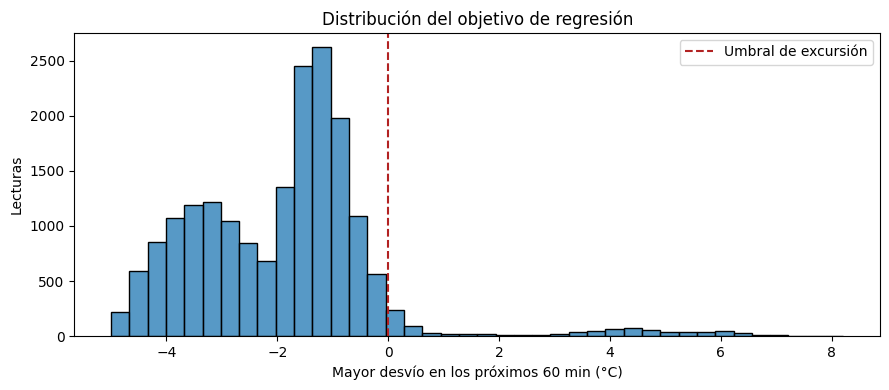

In [19]:
FEATURES_NUMERICAS = ["temperatura_cabina_c", "humedad_cabina_pct", "temp_lag1_c",
                     "temp_pendiente_c_por_min", "distancia_umbral_c"]
FEATURES_CATEGORICAS = ["categoria_logistica", "tipo_camion"]
FEATURES = FEATURES_NUMERICAS + FEATURES_CATEGORICAS

apto = (
    analitico["viaje_identidad_estable"].fillna(False)
    & analitico["match_producto"].eq("both")
    & analitico["match_flota"].eq("both")
    & analitico[FEATURES_NUMERICAS].notna().all(axis=1)
    & analitico[FEATURES_CATEGORICAS].notna().all(axis=1)
    & analitico[FEATURES_CATEGORICAS].ne("").all(axis=1)
    & analitico["horizonte_completo"]
    & analitico["hay_lectura_futura_60min"]
    & analitico[TARGET].notna()
)
modelado = analitico.loc[apto].copy()
display(pd.DataFrame({
    "control": ["Lecturas Silver", "Después de los joins", "Viajes de identidad ambigua",
                "Sin match de producto", "Sin match de flota", "Sin rezago",
                "Sin horizonte completo", "Candidatas para regresión"],
    "filas": [len(iot), len(analitico), int((~analitico["viaje_identidad_estable"]).sum()),
              int(analitico["match_producto"].ne("both").sum()),
              int(analitico["match_flota"].ne("both").sum()),
              int(analitico["temp_lag1_c"].isna().sum()),
              int((~analitico["horizonte_completo"]).sum()), len(modelado)]
}))
print(f"Cobertura final: {len(modelado):,} de {len(iot):,} lecturas Silver "
      f"({100 * len(modelado) / len(iot):.2f} %)")
print("Los motivos de exclusión se superponen; sus filas no deben sumarse.")
print(f"Máximo futuro > 0 en elegibles: {int(modelado[TARGET].gt(0).sum()):,} "
      f"({100 * modelado[TARGET].gt(0).mean():.2f} %)")
if modelado.empty:
    raise ValueError("No quedaron lecturas elegibles para el contrato de regresión")
assert modelado[FEATURES + [TARGET]].notna().all().all()
assert TARGET not in FEATURES and "desviacion_proximos_60min_flag" not in FEATURES
display(modelado[TARGET].describe(percentiles=[.05, .25, .5, .75, .95]).to_frame("°C respecto al umbral"))
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(modelado[TARGET], bins=40, ax=ax)
ax.axvline(0, color="firebrick", linestyle="--", label="Umbral de excursión")
ax.set(xlabel="Mayor desvío en los próximos 60 min (°C)", ylabel="Lecturas",
       title="Distribución del objetivo de regresión")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Separación temporal por viaje: ajuste, validación y prueba

Primero se reserva TEST con viajes posteriores y un margen temporal de 60 minutos. Dentro del bloque anterior se separan viajes enteros para **AJUSTE** y **VALIDACIÓN**. La elección entre regresión lineal y Random Forest se hará con VALIDACIÓN. Después se reajustará el modelo elegido con todo el bloque anterior y se consultará TEST una sola vez para la evaluación final. Las lecturas de viajes que cruzan cualquiera de los cortes se excluyen.


In [20]:
X = modelado[FEATURES].copy()
y = modelado[TARGET].astype(float).copy()
assert X.index.equals(y.index)

ventanas = (analitico.loc[analitico["viaje_id"].isin(modelado["viaje_id"])]
            .groupby("viaje_id")["timestamp"].agg(inicio="min", fin="max")
            .sort_values("inicio"))
if len(ventanas) < 5:
    raise ValueError("Se necesitan al menos cinco viajes para separar ajuste, validación y prueba")

posicion_test = min(len(ventanas) - 1, max(1, int(np.floor(FRACCION_TRAIN_OBJETIVO * len(ventanas)))))
corte_test = ventanas.iloc[posicion_test]["inicio"]
viajes_pretest = ventanas.index[ventanas["fin"].add(HORIZONTE).lt(corte_test)]
viajes_test = ventanas.index[ventanas["inicio"].ge(corte_test)]
viajes_excluidos_test = ventanas.index.difference(viajes_pretest.union(viajes_test))

ventanas_pretest = ventanas.loc[viajes_pretest].sort_values("inicio")
if len(ventanas_pretest) < 3:
    raise ValueError("El bloque anterior a TEST no permite una validación temporal")
FRACCION_AJUSTE_EN_PRETEST = 0.75
posicion_val = min(len(ventanas_pretest) - 1,
                   max(1, int(np.floor(FRACCION_AJUSTE_EN_PRETEST * len(ventanas_pretest)))))
corte_val = ventanas_pretest.iloc[posicion_val]["inicio"]
viajes_ajuste = ventanas_pretest.index[ventanas_pretest["fin"].add(HORIZONTE).lt(corte_val)]
viajes_val = ventanas_pretest.index[ventanas_pretest["inicio"].ge(corte_val)]
viajes_excluidos_val = ventanas_pretest.index.difference(viajes_ajuste.union(viajes_val))

mascara_ajuste = modelado["viaje_id"].isin(viajes_ajuste)
mascara_val = modelado["viaje_id"].isin(viajes_val)
mascara_pretest = modelado["viaje_id"].isin(viajes_pretest)
mascara_test = modelado["viaje_id"].isin(viajes_test)
X_ajuste, y_ajuste = X.loc[mascara_ajuste], y.loc[mascara_ajuste]
X_val, y_val = X.loc[mascara_val], y.loc[mascara_val]
X_pretest, y_pretest = X.loc[mascara_pretest], y.loc[mascara_pretest]
X_test, y_test = X.loc[mascara_test], y.loc[mascara_test]

if any(tabla.empty for tabla in (X_ajuste, X_val, X_pretest, X_test)):
    raise ValueError("Alguna partición quedó vacía; revisar cortes temporales")
assert set(viajes_ajuste).isdisjoint(viajes_val)
assert set(viajes_pretest).isdisjoint(viajes_test)
assert ventanas.loc[viajes_ajuste, "fin"].max() + HORIZONTE < ventanas.loc[viajes_val, "inicio"].min()
assert ventanas.loc[viajes_pretest, "fin"].max() + HORIZONTE < ventanas.loc[viajes_test, "inicio"].min()

print("Cortes VALIDACIÓN / TEST:", corte_val, "/", corte_test)
print("Viajes AJUSTE / VALIDACIÓN / PRETEST / TEST:",
      len(viajes_ajuste), len(viajes_val), len(viajes_pretest), len(viajes_test))
print("Viajes excluidos por cruce o margen en ambos cortes:",
      len(viajes_excluidos_val), "/", len(viajes_excluidos_test))
print("Lecturas AJUSTE / VALIDACIÓN / PRETEST / TEST:",
      len(X_ajuste), len(X_val), len(X_pretest), len(X_test))
display(pd.DataFrame({"AJUSTE": y_ajuste.describe(), "VALIDACIÓN": y_val.describe(),
                      "PRETEST": y_pretest.describe(), "TEST": y_test.describe()}))
display(pd.DataFrame({
    "conjunto": ["AJUSTE", "VALIDACIÓN", "TEST"],
    "lecturas": [len(y_ajuste), len(y_val), len(y_test)],
    "máximo futuro > 0": [int(y_ajuste.gt(0).sum()), int(y_val.gt(0).sum()), int(y_test.gt(0).sum())],
    "% con máximo > 0": [100 * y_ajuste.gt(0).mean(), 100 * y_val.gt(0).mean(), 100 * y_test.gt(0).mean()],
}).round(2))


Cortes VALIDACIÓN / TEST: 2026-08-18 12:12:00 / 2026-08-24 18:54:00
Viajes AJUSTE / VALIDACIÓN / PRETEST / TEST: 514 178 710 181
Viajes excluidos por cruce o margen en ambos cortes: 18 / 14
Lecturas AJUSTE / VALIDACIÓN / PRETEST / TEST: 10636 3684 14693 3751


,AJUSTE,VALIDACIÓN,PRETEST,TEST
count,10636.000000,3684.000000,14693.000000,3751.000000
mean,-1.869682,-2.019606,-1.908968,-1.705784
std,1.768440,1.495594,1.708099,1.751048
min,-5.000000,-4.990000,-5.000000,-4.990000
25%,-3.160000,-3.232500,-3.190000,-2.850000
50%,-1.680000,-1.720000,-1.690000,-1.500000
75%,-1.040000,-1.100000,-1.060000,-0.980000
max,8.210000,6.020000,8.210000,7.390000


,conjunto,lecturas,máximo futuro > 0,% con máximo > 0
0,AJUSTE,10636,562,5.28
1,VALIDACIÓN,3684,129,3.50
2,TEST,3751,212,5.65


## 7. Baseline y regresores: elección en VALIDACIÓN

Se ajustan con AJUSTE la media, la regresión lineal y el bosque aleatorio. Las transformaciones aprendidas quedan dentro de cada `Pipeline`. Se compara el error en las mismas lecturas de VALIDACIÓN y se elige el regresor de menor RMSE allí, antes de ver TEST.


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

preprocesador_lineal = ColumnTransformer([
    ("numericas", StandardScaler(), FEATURES_NUMERICAS),
    ("categoricas", OneHotEncoder(handle_unknown="ignore"), FEATURES_CATEGORICAS),
])
preprocesador_bosque = ColumnTransformer([
    ("numericas", "passthrough", FEATURES_NUMERICAS),
    ("categoricas", OneHotEncoder(handle_unknown="ignore"), FEATURES_CATEGORICAS),
])
modelos = {
    "Dummy media": DummyRegressor(strategy="mean"),
    "Regresión lineal": Pipeline([
        ("preprocesador", preprocesador_lineal), ("modelo", LinearRegression())]),
    "Random Forest": Pipeline([
        ("preprocesador", preprocesador_bosque),
        ("modelo", RandomForestRegressor(n_estimators=200, max_depth=8,
                                         min_samples_split=5, random_state=SEMILLA, n_jobs=-1))]),
}
predicciones_val = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_ajuste, y_ajuste)
    predicciones_val[nombre] = modelo.predict(X_val)
print("Modelos ajustados solo con AJUSTE; TEST aún no se ha consultado")


Modelos ajustados solo con AJUSTE; TEST aún no se ha consultado


## 8. Selección con VALIDACIÓN y evaluación final en TEST

Se elige el regresor con menor RMSE de VALIDACIÓN. Luego se reajustan **ese regresor y el baseline** con PRETEST, que contiene todo el historial anterior a TEST que superó el margen temporal. TEST se usa para una evaluación final, no para elegir entre candidatos.


In [22]:
from sklearn.base import clone

def metricas(y_real, pred):
    mse = mean_squared_error(y_real, pred)
    return {"MAE": mean_absolute_error(y_real, pred), "MSE": mse,
            "RMSE": np.sqrt(mse), "R2": r2_score(y_real, pred)}

filas_val = []
for nombre, pred in predicciones_val.items():
    m = metricas(y_val, pred)
    filas_val.append({"Modelo": nombre, "MAE VALIDACIÓN (°C)": m["MAE"],
                      "RMSE VALIDACIÓN (°C)": m["RMSE"], "R² VALIDACIÓN": m["R2"]})
resultados_val = pd.DataFrame(filas_val).set_index("Modelo")
seleccion = resultados_val.drop(index="Dummy media")["RMSE VALIDACIÓN (°C)"].idxmin()
print("Comparación y selección realizadas únicamente con VALIDACIÓN:")
display(resultados_val.sort_values("RMSE VALIDACIÓN (°C)").round(3))
print("Regresor seleccionado:", seleccion)

modelos_finales = {
    "Dummy media": clone(modelos["Dummy media"]),
    seleccion: clone(modelos[seleccion]),
}
filas_test = []
predicciones_test = {}
for nombre, modelo in modelos_finales.items():
    modelo.fit(X_pretest, y_pretest)
    pred = modelo.predict(X_test)
    predicciones_test[nombre] = pred
    m = metricas(y_test, pred)
    filas_test.append({"Modelo": nombre, "MAE TEST (°C)": m["MAE"],
                       "MSE TEST (°C²)": m["MSE"], "RMSE TEST (°C)": m["RMSE"],
                       "R² TEST": m["R2"]})
resultados_test = pd.DataFrame(filas_test).set_index("Modelo")
rmse_baseline = resultados_test.loc["Dummy media", "RMSE TEST (°C)"]
resultados_test["Mejora RMSE vs baseline (%)"] = (
    100 * (rmse_baseline - resultados_test["RMSE TEST (°C)"]) / rmse_baseline
)
print("Evaluación final en TEST:")
display(resultados_test.round(3))


Comparación y selección realizadas únicamente con VALIDACIÓN:


,MAE VALIDACIÓN (°C),RMSE VALIDACIÓN (°C),R² VALIDACIÓN
Modelo,,,
Random Forest,0.720,1.020,0.535
Regresión lineal,0.765,1.059,0.499
Dummy media,1.165,1.503,-0.010


Regresor seleccionado: Random Forest
Evaluación final en TEST:


,MAE TEST (°C),MSE TEST (°C²),RMSE TEST (°C),R² TEST,Mejora RMSE vs baseline (%)
Modelo,,,,,
Dummy media,1.236,3.107,1.763,-0.013,0.000
Random Forest,0.727,1.235,1.112,0.597,36.938


## 9. Errores generales y en excursiones futuras

Se estudian los residuos `real − predicho`, en especial las **subestimaciones**. Como los máximos futuros positivos son poco frecuentes, se calcula además el error en el subconjunto de TEST donde `y > 0`. Esta segunda lectura es diagnóstica: no reemplaza las métricas generales ni convierte automáticamente el regresor en un sistema de alertas.


Regresor elegido en VALIDACIÓN: Random Forest


,TEST completo
Sesgo medio (°C),-0.003483
Mediana del error (°C),-0.129508
P95 del error absoluto (°C),1.939020
Proporción de subestimaciones,0.422821
P95 de la subestimación (°C),1.788572


Lecturas con excursión futura en TEST: 212 de 3751 (5.65 %)


,MAE excursiones (°C),RMSE excursiones (°C),Subestimación media (°C),P95 subestimación (°C),% predicciones ≤ 0 ante excursión
Modelo,,,,,
Dummy media,4.973,5.522,4.973,8.403,100.000
Random Forest,2.326,3.040,2.292,6.457,59.434


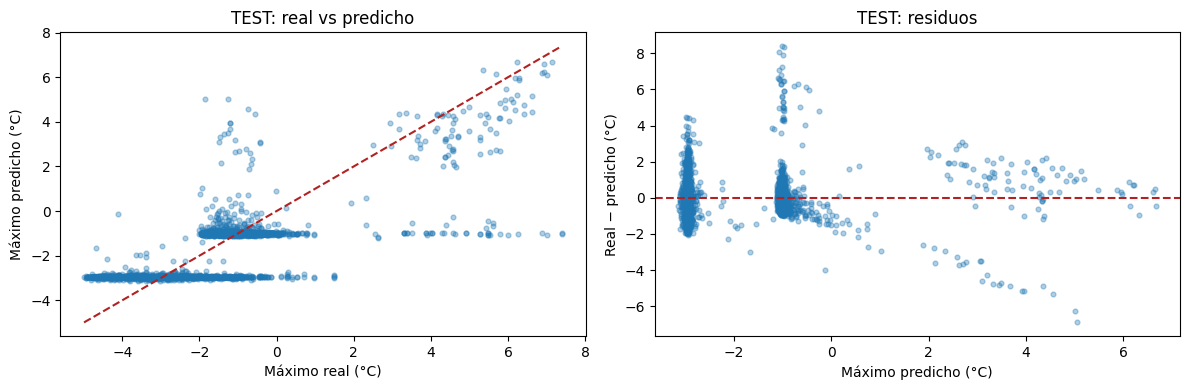

In [23]:
y_pred = predicciones_test[seleccion]
residuos = y_test.to_numpy() - y_pred
print("Regresor elegido en VALIDACIÓN:", seleccion)
display(pd.Series({
    "Sesgo medio (°C)": np.mean(residuos),
    "Mediana del error (°C)": np.median(residuos),
    "P95 del error absoluto (°C)": np.percentile(np.abs(residuos), 95),
    "Proporción de subestimaciones": np.mean(residuos > 0),
    "P95 de la subestimación (°C)": np.percentile(np.maximum(residuos, 0), 95),
}).to_frame("TEST completo"))

positivos = y_test.to_numpy() > 0
print(f"Lecturas con excursión futura en TEST: {positivos.sum()} de {len(y_test)} "
      f"({100 * positivos.mean():.2f} %)")
if positivos.any():
    filas_positivos = []
    for nombre, pred in predicciones_test.items():
        error = y_test.to_numpy()[positivos] - pred[positivos]
        filas_positivos.append({
            "Modelo": nombre,
            "MAE excursiones (°C)": np.mean(np.abs(error)),
            "RMSE excursiones (°C)": np.sqrt(np.mean(error ** 2)),
            "Subestimación media (°C)": np.mean(np.maximum(error, 0)),
            "P95 subestimación (°C)": np.percentile(np.maximum(error, 0), 95),
            "% predicciones ≤ 0 ante excursión": 100 * np.mean(pred[positivos] <= 0),
        })
    display(pd.DataFrame(filas_positivos).set_index("Modelo").round(3))
else:
    print("TEST no contiene excursiones futuras; esta partición no permite evaluar ese caso operativo")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_test, y_pred, alpha=.35, s=12)
limites = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(limites, limites, "--", color="firebrick")
axes[0].set(xlabel="Máximo real (°C)", ylabel="Máximo predicho (°C)", title="TEST: real vs predicho")
axes[1].scatter(y_pred, residuos, alpha=.35, s=12)
axes[1].axhline(0, linestyle="--", color="firebrick")
axes[1].set(xlabel="Máximo predicho (°C)", ylabel="Real − predicho (°C)", title="TEST: residuos")
plt.tight_layout()
plt.show()


## 10. Interpretación y límites

Completar después de ejecutar sobre los Silver definitivos:

1. ¿Qué proporción de lecturas y viajes quedó fuera por cobertura, rezagos u horizonte incompleto? Los motivos se superponen: no sumar sus recuentos.
2. ¿Cuántos desacuerdos hay entre `máximo futuro > 0` y el flag Silver? Registrar los casos e investigar la regla de generación antes de atribuir una causa.
3. ¿Qué regresor superó el baseline en VALIDACIÓN? ¿El **regresor seleccionado antes de TEST** mantuvo la mejora en TEST?
4. En las excursiones futuras (`y > 0`), ¿cuánto subestima y cuántas predicciones quedan en `≤ 0`? ¿Qué tolerancia en °C acepta la operación?
5. ¿Cómo cambian los errores por categoría, camión y periodo? Investigar después de fijar la comparación principal.

**Límites:** datos sintéticos, cobertura parcial de productos y camiones, ventanas completas únicamente donde hay observación temporal suficiente, dependencia entre lecturas de un mismo viaje y ausencia de una tolerancia operativa aprobada. La comparación en TEST evalúa este corte histórico; no demuestra ahorro, seguridad ni desempeño en producción.
